In [2]:
import os
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
os.environ['XLA_FLAGS'] = '--xla_disable_all_hlo_passes'
import tensorflow as tf

# Disable XLA JIT compilation
tf.config.optimizer.set_jit(False)

# Configure GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [3]:
!nvidia-smi

Tue Mar 31 18:25:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   29C    P8             10W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
image_dir = "../dataset/image"
mask_dir  = "../dataset/mask"

images = os.listdir(image_dir)

print("Total images:", len(images))
print("Total Masks",len(mask_dir))

Total images: 289
Total Masks 15


Image shape: (375, 1242, 3)


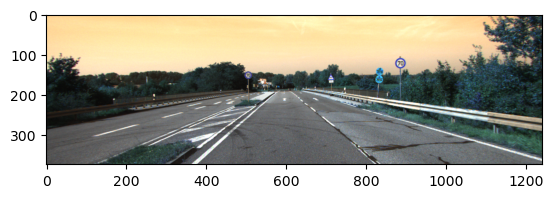

In [5]:
sample = images[10]

img = cv2.imread(os.path.join(image_dir, sample))
print("Image shape:", img.shape)

plt.imshow(img)

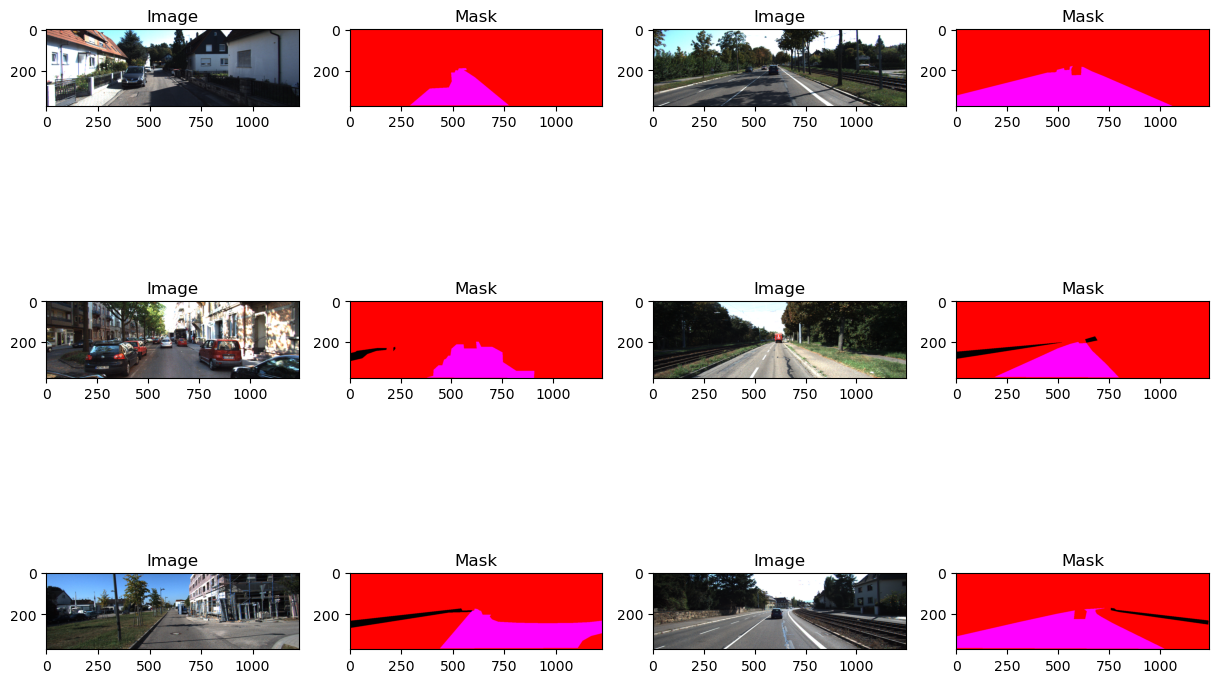

In [6]:
plt.figure(figsize=(15,10))

for i in range(6):

    sample = random.choice(images)

    prefix, rest = sample.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    img = cv2.imread(os.path.join(image_dir, sample))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, mask_name))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i*2+1)
    plt.imshow(img)
    plt.title("Image")

    plt.subplot(3,4,i*2+2)
    plt.imshow(mask)
    plt.title("Mask")

plt.show()

In [7]:
pixels = []

for img_name in images[:50]:
    img = cv2.imread(os.path.join(image_dir, img_name))
    pixels.append(img.mean())

print("Mean pixel intensity:", np.mean(pixels))

Mean pixel intensity: 94.87449656110216


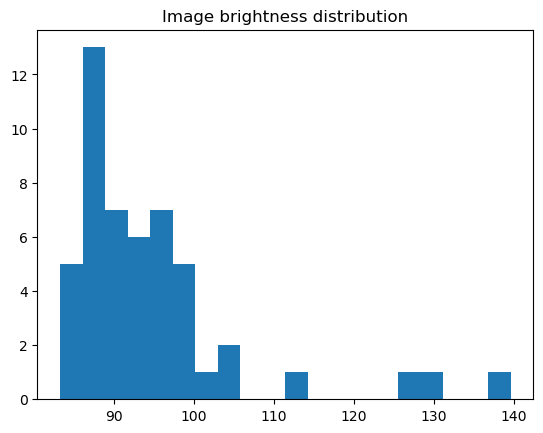

In [8]:
plt.hist(pixels, bins=20)
plt.title("Image brightness distribution")
plt.show()

In [9]:
for img_name in images[:5]:

    prefix, rest = img_name.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    print(img_name, "->", mask_name)

umm_000000.png -> umm_road_000000.png
umm_000001.png -> umm_road_000001.png
umm_000002.png -> umm_road_000002.png
umm_000004.png -> umm_road_000004.png
umm_000003.png -> umm_road_000003.png


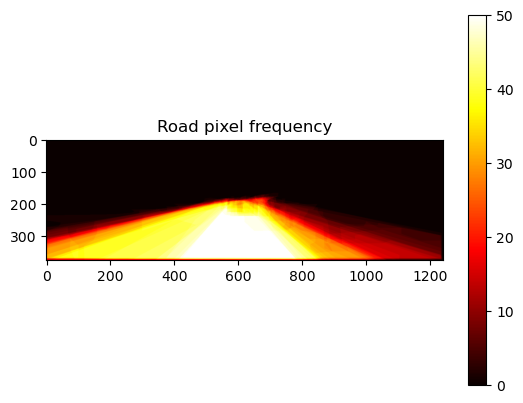

In [10]:
heatmap = np.zeros((375,1242))

for img_name in images[:50]:

    prefix, rest = img_name.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    mask = cv2.imread(os.path.join(mask_dir, mask_name))

    road = mask[:,:,0] == 255

    road = cv2.resize(road.astype(np.uint8), (1242,375))

    heatmap += road

plt.imshow(heatmap, cmap="hot")
plt.title("Road pixel frequency")
plt.colorbar()
plt.show()

In [11]:
def get_mask_name(img_name):
    prefix, rest = img_name.split("_",1)
    return f"{prefix}_road_{rest}"

In [12]:
IMG_SIZE = 256

def load_sample(img_name):

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, get_mask_name(img_name))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path)

    # road pixels
    road = mask[:,:,0] == 255
    mask = road.astype(np.float32)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    mask = np.expand_dims(mask,axis=-1)

    return img, mask

In [13]:
X=[]
Y=[]

for img_name in images:
    
    img,mask = load_sample(img_name)

    X.append(img)
    Y.append(mask)

X = np.array(X)/255.0
Y = np.array(Y)

print(X.shape,Y.shape)

(289, 256, 256, 3) (289, 256, 256, 1)


In [14]:
from sklearn.model_selection import train_test_split

X_train,X_val,Y_train,Y_val = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [15]:
def build_resnet_unet():

    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Encoder layers (skip connections)
    s1 = base.get_layer("conv1_relu").output
    s2 = base.get_layer("conv2_block3_out").output
    s3 = base.get_layer("conv3_block4_out").output
    s4 = base.get_layer("conv4_block6_out").output

    b1 = base.get_layer("conv5_block3_out").output

    # Decoder
    d1 = UpSampling2D((2,2))(b1)
    d1 = Concatenate()([d1,s4])
    d1 = Conv2D(512,3,padding="same",activation="relu")(d1)

    d2 = UpSampling2D((2,2))(d1)
    d2 = Concatenate()([d2,s3])
    d2 = Conv2D(256,3,padding="same",activation="relu")(d2)

    d3 = UpSampling2D((2,2))(d2)
    d3 = Concatenate()([d3,s2])
    d3 = Conv2D(128,3,padding="same",activation="relu")(d3)

    d4 = UpSampling2D((2,2))(d3)
    d4 = Concatenate()([d4,s1])
    d4 = Conv2D(64,3,padding="same",activation="relu")(d4)

    d5 = UpSampling2D((2,2))(d4)
    outputs = Conv2D(1,1,activation="sigmoid")(d5)

    model = Model(base.input,outputs)

    return model

In [16]:
model = build_resnet_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

2026-03-31 18:25:22.093647: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-03-31 18:25:22.093694: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: default
2026-03-31 18:25:22.093702: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: default
2026-03-31 18:25:22.093811: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 560.35.5
2026-03-31 18:25:22.093834: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 550.163.1
2026-03-31 18:25:22.093841: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 550.163.1 does not match DSO version 560.35.5 -- cannot find working devices in this configuration


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 40,804,225 (155.66 MB)

 Trainable params: 40,751,105 (155.45 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=8
)

Epoch 1/40


2026-03-31 18:25:56.430244: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


14/29 ━━━━━━━━━━━━━━━━━━━━ 1:07 4s/step - accuracy: 0.6724 - loss: 0.8541

In [22]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
import tarfile, os

model.export("/kaggle/working/road_seg_savedmodel")

with tarfile.open("/kaggle/working/model.tar.gz", "w:gz") as tar:
    tar.add("/kaggle/working/road_seg_savedmodel", arcname=".")

In [ ]:
idx = 4
pred = model.predict(X_val[idx:idx+1])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[idx])
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(Y_val[idx].squeeze())
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(pred[0].squeeze() > 0.5)
plt.title("Prediction")

plt.show()

In [ ]:
video_path = "/kaggle/input/datasets/sakshaymahna/kittiroadsegmentation/testing/solidYellowLeft.mp4"

cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

print(width, height, fps)

In [ ]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter("/kaggle/working/output.mp4",fourcc,fps,(width, height))

In [ ]:
IMG_SIZE = 256

def process_frame(frame):

    original = frame.copy()

    small = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    small = small / 255.0

    pred = model.predict(small[np.newaxis,...])[0]

    mask = pred.squeeze() > 0.5

    mask = cv2.resize(mask.astype(np.uint8), (width, height))

    overlay = original.copy()
    overlay[mask == 1] = [0,255,0]

    return overlay

In [ ]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    result = process_frame(frame)
    out.write(result)
cap.release()
out.release()